In [2]:
import pandas as pd
intl = pd.read_csv('data/international_results.csv')
print(intl.shape)
print(intl.head())

(46442, 9)
         date home_team away_team  home_score  away_score tournament     city  \
0  1872-11-30  Scotland   England           0           0   Friendly  Glasgow   
1  1873-03-08   England  Scotland           4           2   Friendly   London   
2  1874-03-07  Scotland   England           2           1   Friendly  Glasgow   
3  1875-03-06   England  Scotland           2           2   Friendly   London   
4  1876-03-04  Scotland   England           3           0   Friendly  Glasgow   

    country  neutral  
0  Scotland    False  
1   England    False  
2  Scotland    False  
3   England    False  
4  Scotland    False  


### Convert date column and check data quality

Right now the date column is just text (a string), even though it looks like a date. We need to convert it to an actual datetime type so pandas can sort and compare dates properly — this is critical since our whole approach depends on processing matches in chronological order.

In [3]:
intl['date'] = pd.to_datetime(intl['date'])
print(intl.dtypes)

date          datetime64[us]
home_team                str
away_team                str
home_score             int64
away_score             int64
tournament               str
city                     str
country                  str
neutral                 bool
dtype: object


In [4]:
print(intl.isnull().sum())
#print()
print(intl['neutral'].dtype)
print(intl['neutral'].unique())

date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64
bool
[False  True]


### Filter to matches from 2000 onwards

Here's the reasoning before you write the code: we have data going back to 1872, but we don't want to train on 150 years of football. The game has changed completely — tactics, athleticism, squad management are all unrecognisable from 50 years ago. More importantly, Elo ratings need time to "warm up" — if we start from 2012, every team begins at the same rating (1500), so Brazil and Bhutan look identical on day 1. Starting from 2000 gives ratings ~12 years to diverge into realistic values before we start training

In [5]:
df = intl[intl['date'] >= '2000-01-01']
df = df.sort_values('date').reset_index(drop=True) #if you don't have the reset_index function, the dataframe(df)
# will start from the index of corresponding intl columns. For example it may start from 1534 and go on 1544, 1545
# and so on but it is better to start indexing the columns from 0 onwards. drop = true performs the function of 
# dropping the old indices of the corresponding intl columns
print(df.shape)
print(df['date'].min(), df['date'].max())
print(df.head(3))

(22795, 9)
2000-01-04 00:00:00 2024-03-26 00:00:00
        date            home_team away_team  home_score  away_score  \
0 2000-01-04                Egypt      Togo           2           1   
1 2000-01-07              Tunisia      Togo           7           0   
2 2000-01-08  Trinidad and Tobago    Canada           0           0   

  tournament           city              country  neutral  
0   Friendly          Aswan                Egypt    False  
1   Friendly          Tunis              Tunisia    False  
2   Friendly  Port of Spain  Trinidad and Tobago    False  


In [6]:
from collections import deque, defaultdict

IINITIAL_ELO = 1500
K = 30

def expected_score(rating_a, rating_b):
    return 1/(1+10**((rating_b-rating_a)/400))

def actual_score(goals_for, goals_against):
    if goals_for>goals_against:
        return 1.0
    if goals_for == goals_against:
        return 0.5
    else:
        return 0.0
    
def goal_diff_multiplier(goal_diff):
    gd = abs(goal_diff)
    if gd<=1:
        return 1
    elif gd == 2:
        return 1.5
    else:
        return (11+gd)/8

elo = {}
home_elo_pre = []
away_elo_pre = []

for idx, row in df.iterrows():
    home, away = row['home_team'], row['away_team']
    hs, as_ = row['home_score'], row['away_score']

    r_home = elo.get(home, IINITIAL_ELO)
    r_away = elo.get(away, IINITIAL_ELO)

    home_elo_pre.append(r_home)
    away_elo_pre.append(r_away)

    exp_home = expected_score(r_home, r_away)
    exp_away = expected_score(r_away, r_home)

    act_home = actual_score(hs, as_)
    act_away = actual_score(as_, hs)

    gd_mult = goal_diff_multiplier(hs-as_)

    elo[home] = r_home + K*gd_mult*(act_home-exp_home)
    elo[away] = r_away + K*gd_mult*(act_away-exp_away)

df['home_elo'] = home_elo_pre
df['away_elo'] = away_elo_pre

print(df[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'home_elo', 'away_elo']].head(10))


        date            home_team away_team  home_score  away_score  home_elo  \
0 2000-01-04                Egypt      Togo           2           1    1500.0   
1 2000-01-07              Tunisia      Togo           7           0    1500.0   
2 2000-01-08  Trinidad and Tobago    Canada           0           0    1500.0   
3 2000-01-09         Burkina Faso     Gabon           1           1    1500.0   
4 2000-01-09            Guatemala   Armenia           1           1    1500.0   
5 2000-01-09          Ivory Coast     Egypt           2           0    1500.0   
6 2000-01-09               Mexico      Iran           2           1    1500.0   
7 2000-01-11              Bermuda    Canada           0           2    1500.0   
8 2000-01-11         Burkina Faso  Cameroon           2           2    1500.0   
9 2000-01-13              Senegal  Cameroon           0           0    1500.0   

   away_elo  
0    1500.0  
1    1485.0  
2    1500.0  
3    1500.0  
4    1500.0  
5    1515.0  
6    1500.

In [7]:
top_elos = pd.Series(elo).sort_values(ascending=False).head(10)
print(top_elos)

Argentina      2114.612327
France         2032.747326
Brazil         2030.529149
Spain          2014.474544
England        2012.808228
Colombia       2009.167216
Portugal       1995.020067
Belgium        1988.424290
Netherlands    1976.626190
Uruguay        1972.883102
dtype: float64


## Recent form feature
The concept
Elo captures long-term team strength, but it doesn't capture momentum — is a team on a hot streak or a slump right now? "Recent form" fixes this by looking at just the last 5 matches for each team.
We'll compute two things per team, going into each match:

Form points: average points per game over last 5 matches (Win=3, Draw=1, Loss=0), scaled to a 0-15 range so it's comparable to a "total points from 5 games" feel

Form goal difference: average goal difference over last 5 matches

The mechanism: deque(maxlen=5)
We'll use Python's deque (double-ended queue) with maxlen=5 — this is a list-like structure that automatically drops the oldest item when you add a 6th item. Perfect for "last 5 matches" tracking without manual list-trimming logic.
Edge case: what about a team's first few matches?
If a team has played 0 matches so far in our window, they have no history to compute form from. We'll default to a neutral value: 7.5 form points (the midpoint of 0-15) and 0 goal difference. This says "we have no information, assume average."

In [8]:
team_history = defaultdict(lambda: deque(maxlen = 5))

NEUTRAL_FORM_POINTS = 7.5
NEUTRAL_FORM_GD = 0.0

home_form_pts = []
away_form_pts = []
home_form_gd = []
away_form_gd = []

for idx, row in df.iterrows():
    home, away = row['home_team'], row['away_team']
    hs, as_ = row['home_score'], row['away_score']

    h_hist = team_history[home]
    if len(h_hist) == 0:
        home_form_pts.append(NEUTRAL_FORM_POINTS)
        home_form_gd.append(NEUTRAL_FORM_GD)
    else:
        pts = [m[0] for m in h_hist]
        gd = [m[1] for m in h_hist]
        home_form_pts.append(sum(pts)/len(pts)*5)
        home_form_gd.append(sum(gd)/len(gd))
    
    a_hist = team_history[away]
    if len(a_hist) == 0:
        away_form_pts.append(NEUTRAL_FORM_POINTS)
        away_form_gd.append(NEUTRAL_FORM_GD)
    else:
        pts = [m[0] for m in a_hist]
        gd = [m[1] for m in a_hist]
        away_form_pts.append(sum(pts)/len(pts)*5)
        away_form_gd.append(sum(gd)/len(gd))
    
    if hs>as_:
        home_pts, away_pts = 3, 0
    elif hs == as_:
        home_pts, away_pts = 1, 1
    else:
        home_pts, away_pts = 0,3
    
    team_history[home].append((home_pts, hs-as_))
    team_history[away].append((away_pts, as_-hs))

df['home_form_pts'] = home_form_pts
df['away_form_pts'] = away_form_pts
df['home_form_gd'] = home_form_gd
df['away_form_gd'] = away_form_gd

print(df[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'home_form_pts', 'away_form_pts']].head(10))

        date            home_team away_team  home_score  away_score  \
0 2000-01-04                Egypt      Togo           2           1   
1 2000-01-07              Tunisia      Togo           7           0   
2 2000-01-08  Trinidad and Tobago    Canada           0           0   
3 2000-01-09         Burkina Faso     Gabon           1           1   
4 2000-01-09            Guatemala   Armenia           1           1   
5 2000-01-09          Ivory Coast     Egypt           2           0   
6 2000-01-09               Mexico      Iran           2           1   
7 2000-01-11              Bermuda    Canada           0           2   
8 2000-01-11         Burkina Faso  Cameroon           2           2   
9 2000-01-13              Senegal  Cameroon           0           0   

   home_form_pts  away_form_pts  
0            7.5            7.5  
1            7.5            0.0  
2            7.5            7.5  
3            7.5            7.5  
4            7.5            7.5  
5            7

## Goals scored/conceded rolling averages
Same pattern as form. For each team going into each match, we want their average goals scored and conceded over their last 5 matches. This captures attacking and defensive output independently from form points — a team can win ugly (good form, low scoring) or lose in a high-scoring game (bad form, high scoring). These are separate signals.
For teams with no history yet, we'll default to 1.2 — roughly the global average goals scored per team per match.

In [9]:
team_goal_history = defaultdict(lambda: deque(maxlen = 5))

NEUTRAL_GOALS = 1.2

home_avg_scored = []
home_avg_conceded = []
away_avg_scored = []
away_avg_conceded = []

for idx, row in df.iterrows():
    home, away = row['home_team'], row['away_team']
    hs, as_ = row['home_score'], row['away_score']

    h_hist = team_goal_history[home]
    if len(h_hist) == 0:
        home_avg_scored.append(NEUTRAL_GOALS)
        home_avg_conceded.append(NEUTRAL_GOALS)
    else:
        gs = [m[0] for m in h_hist]
        gc = [m[1] for m in h_hist]
        home_avg_scored.append(sum(gs)/len(h_hist))
        home_avg_conceded.append(sum(gc)/len(h_hist))
    
    a_hist = team_goal_history[away]
    if len(a_hist) == 0:
        away_avg_scored.append(NEUTRAL_GOALS)
        away_avg_conceded.append(NEUTRAL_GOALS)
    else:
        gs = [m[0] for m in a_hist]
        gc = [m[1] for m in a_hist]
        away_avg_scored.append(sum(gs)/len(a_hist))
        away_avg_conceded.append(sum(gc)/len(a_hist))
    
    team_goal_history[home].append((hs, as_))
    team_goal_history[away].append((as_, hs))

df['home_avg_scored'] = home_avg_scored
df['home_avg_conceded'] = home_avg_conceded
df['away_avg_scored'] = away_avg_scored
df['away_avg_conceded'] = away_avg_conceded

print(df[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'home_avg_scored', 'home_avg_conceded', 'away_avg_scored', 'away_avg_conceded']].head(10))


        date            home_team away_team  home_score  away_score  \
0 2000-01-04                Egypt      Togo           2           1   
1 2000-01-07              Tunisia      Togo           7           0   
2 2000-01-08  Trinidad and Tobago    Canada           0           0   
3 2000-01-09         Burkina Faso     Gabon           1           1   
4 2000-01-09            Guatemala   Armenia           1           1   
5 2000-01-09          Ivory Coast     Egypt           2           0   
6 2000-01-09               Mexico      Iran           2           1   
7 2000-01-11              Bermuda    Canada           0           2   
8 2000-01-11         Burkina Faso  Cameroon           2           2   
9 2000-01-13              Senegal  Cameroon           0           0   

   home_avg_scored  home_avg_conceded  away_avg_scored  away_avg_conceded  
0              1.2                1.2              1.2                1.2  
1              1.2                1.2              1.0            

## Home advantage feature + target variable
Two quick things to add before we build the train/test split.
Home advantage: the neutral column already tells us everything. If neutral=False, the home team is actually playing at home (real advantage). If neutral=True, it's a neutral venue (World Cup host country, tournament on neutral ground). We'll encode this as a simple integer: 1 = real home advantage, 0 = neutral.
Target variable: what we're predicting. Three possible outcomes — Home win (H), Draw (D), Away win (A).

In [10]:
df['is_home_advantage'] = (~df['neutral']).astype(int)

def get_result(row):
    if row['home_score']>row['away_score']:
        return 'H'
    elif row['home_score'] == row['away_score']:
        return 'D'
    else:
        return 'A'

df['target'] = df.apply(get_result, axis = 1)

print(df['target'].value_counts(normalize = True).round(3))
print()
print(df[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'is_home_advantage', 'target']].head(5))

target
H    0.482
A    0.285
D    0.233
Name: proportion, dtype: float64

        date            home_team away_team  home_score  away_score  \
0 2000-01-04                Egypt      Togo           2           1   
1 2000-01-07              Tunisia      Togo           7           0   
2 2000-01-08  Trinidad and Tobago    Canada           0           0   
3 2000-01-09         Burkina Faso     Gabon           1           1   
4 2000-01-09            Guatemala   Armenia           1           1   

   is_home_advantage target  
0                  1      H  
1                  1      H  
2                  1      D  
3                  1      D  
4                  0      D  


## Train/test split

Now we separate data into training and test sets.


In [13]:
feature_cols = [
    'home_elo', 'away_elo',
    'home_form_pts', 'away_form_pts',
    'home_form_gd', 'away_form_gd',
    'home_avg_scored', 'away_avg_scored',
    'home_avg_conceded', 'away_avg_conceded',
    'is_home_advantage'
]

train_df = df[(df['date']>='2012-01-01') & (df['date']<='2021-12-31')].copy()
test_df = df[(df['date']>='2022-11-01') & (df['tournament'] == 'FIFA World Cup')].copy()

X_train = train_df[feature_cols]
y_train = train_df['target']
X_test = test_df[feature_cols]
y_test = test_df['target']

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

Training samples: 9146
Test samples: 64

Training target distribution:
target
H    0.479
A    0.288
D    0.233
Name: proportion, dtype: float64


## Scale features and train the model
Why scaling matters

Our features are on very different numerical scales:

Elo ratings: roughly 900–2100
Form points: 0–15
Goals averaged: 0–5
Home advantage: 0 or 1

Logistic regression works by multiplying each feature by a coefficient and summing them up. If Elo is in the thousands and home advantage is 0/1, the model will naturally assign huge coefficients to home advantage just to make it "loud enough" to compete — not because it's more important. StandardScaler fixes this by converting every feature to mean=0, std=1, putting them all on a level playing field.

Critical rule for scaling

You fit the scaler only on training data, then apply it to both train and test. If you fit on all data including the test set, information about the test set's distribution leaks into your scaling — another form of data leakage.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter = 1000, random_state = 42)
model.fit(X_train_scaled, y_train)

print(f"Model Classes: {model.classes_}")
print(f"Training Accuracy: {round(model.score(X_train_scaled, y_train), 3)}")
print(f"Test Accuracy (2022 WC): {round(model.score(X_test_scaled, y_test), 3)}")

Model Classes: ['A' 'D' 'H']
Training Accuracy: 0.59
Test Accuracy (2002 WC): 0.547


## Evaluate properly

Accuracy alone is misleading with imbalanced classes

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred, labels = ['A', 'D', 'H']))

              precision    recall  f1-score   support

           A       0.52      0.57      0.55        21
           D       0.50      0.07      0.12        15
           H       0.56      0.79      0.66        28

    accuracy                           0.55        64
   macro avg       0.53      0.47      0.44        64
weighted avg       0.54      0.55      0.49        64



## Confusion matrix heatmap

Now let's visualise this with seaborn

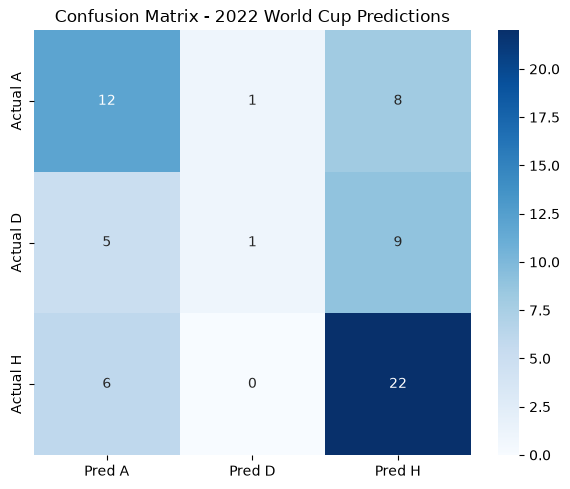

In [21]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels = ['A', 'D', 'H'])

plt.figure(figsize = (6,5))

sns.heatmap(cm, annot=True, cmap = "Blues", 
            xticklabels = ['Pred A', 'Pred D', 'Pred H'],
            yticklabels = ['Actual A', 'Actual D', 'Actual H'])

plt.title('Confusion Matrix - 2022 World Cup Predictions')
plt.tight_layout()
plt.show()

## Feature importance (coefficients)

This is where logistic regression becomes interpretable — unlike a neural network which is a black box, you can directly read what the model learned

In [22]:
import pandas as pd

coef_df = pd.DataFrame(
    model.coef_,
    columns = feature_cols,
    index = model.classes_
)

print(coef_df.round(3))

   home_elo  away_elo  home_form_pts  away_form_pts  home_form_gd  \
A    -0.789     0.849          0.095         -0.143        -0.054   
D     0.039    -0.016         -0.010         -0.016         0.008   
H     0.750    -0.834         -0.085          0.159         0.045   

   away_form_gd  home_avg_scored  away_avg_scored  home_avg_conceded  \
A         0.025            0.054            0.040              0.132   
D         0.049           -0.068           -0.028             -0.075   
H        -0.074            0.014           -0.012             -0.057   

   away_avg_conceded  is_home_advantage  
A             -0.004             -0.147  
D             -0.098              0.002  
H              0.101              0.145  
